c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_f

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


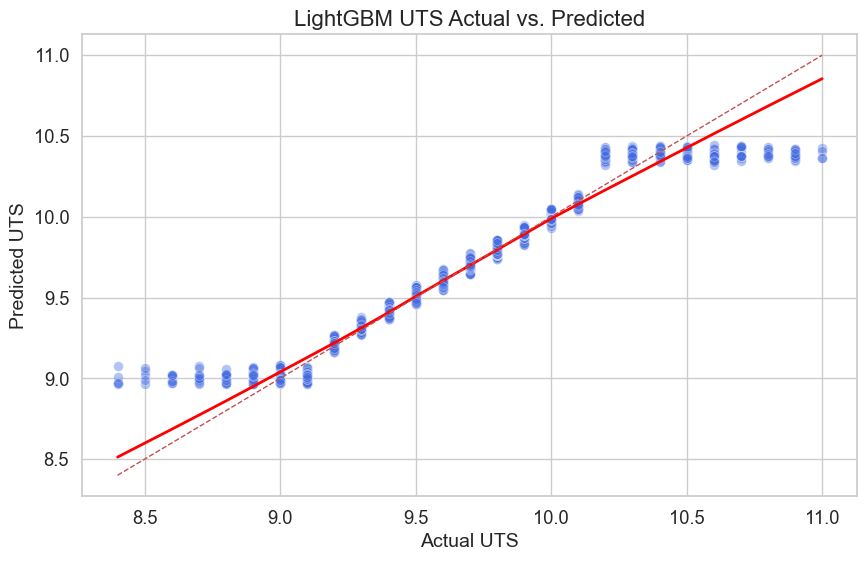

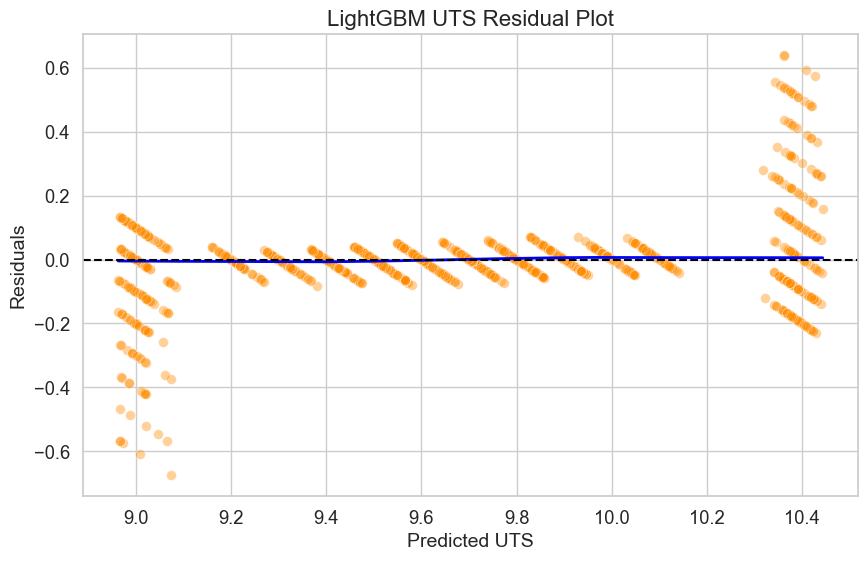

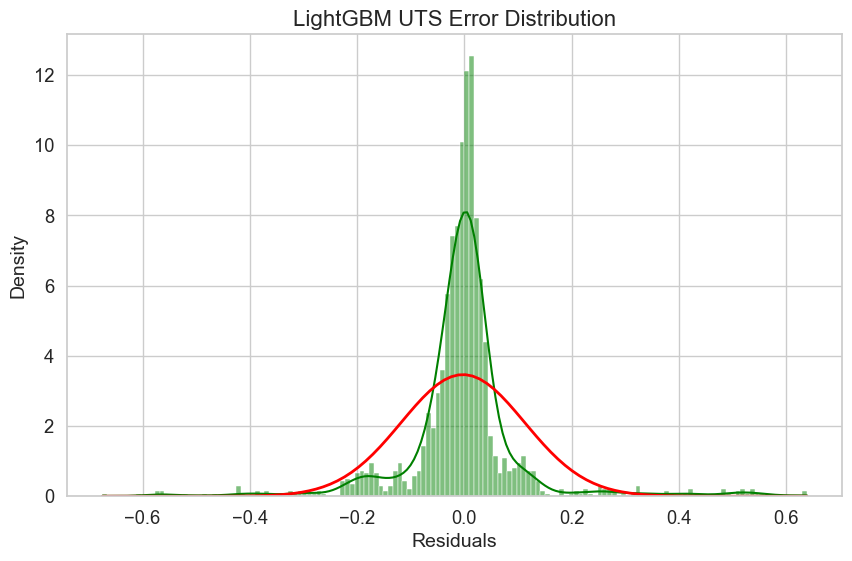

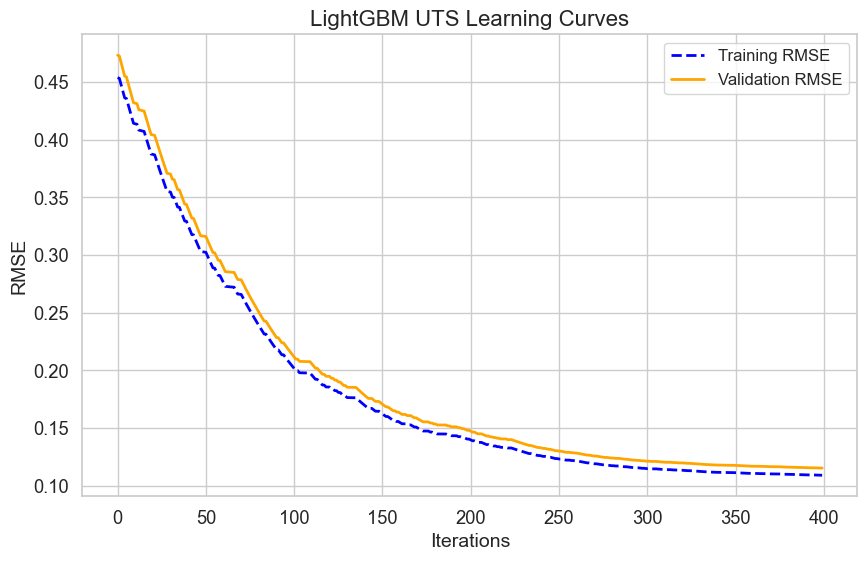

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_f

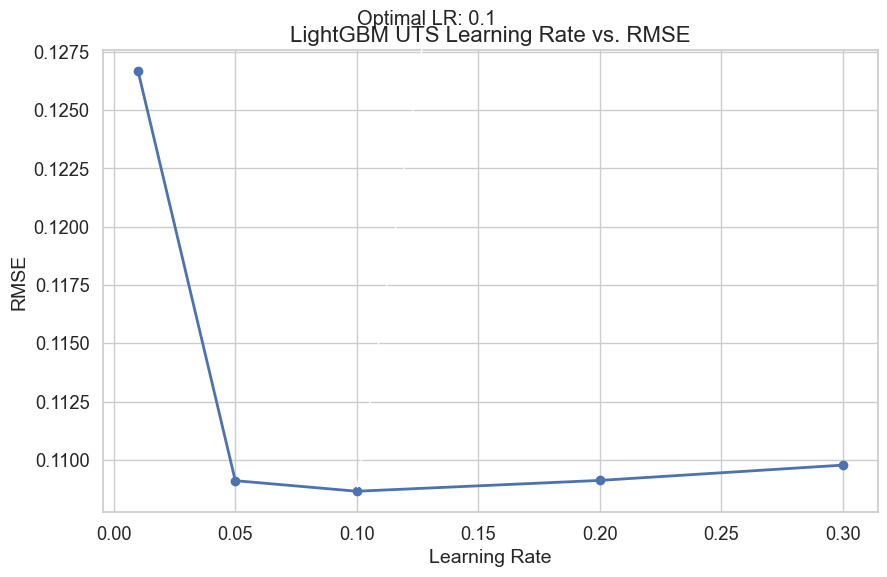

<Figure size 1000x600 with 0 Axes>

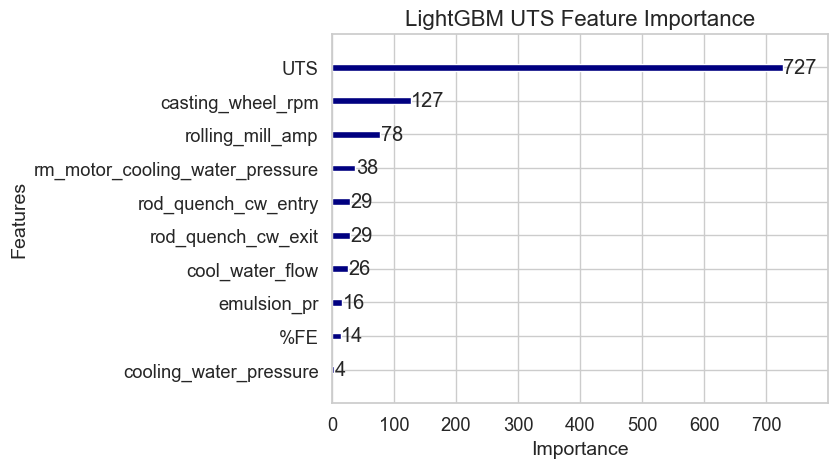

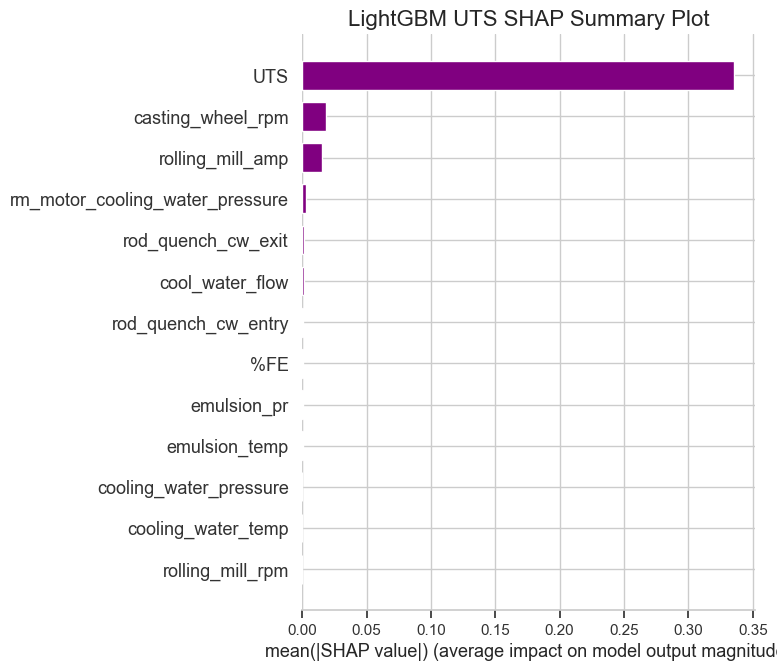

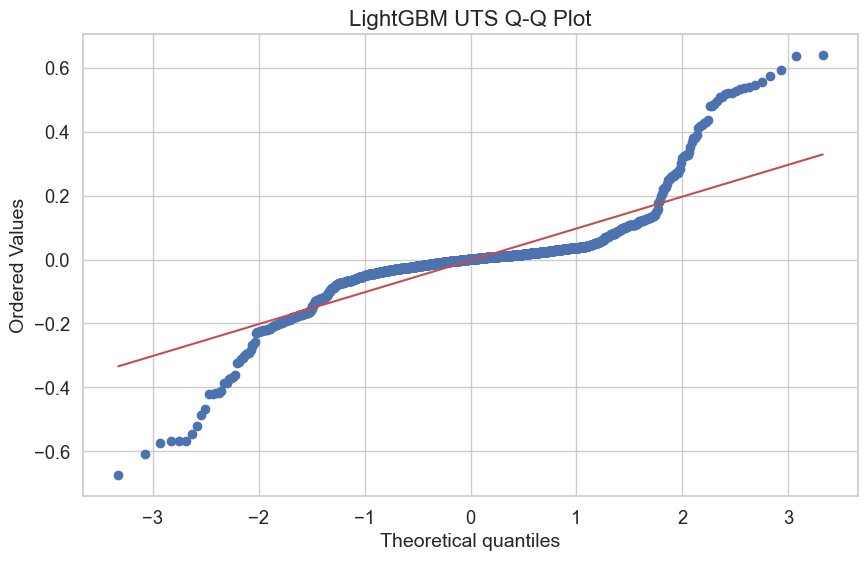

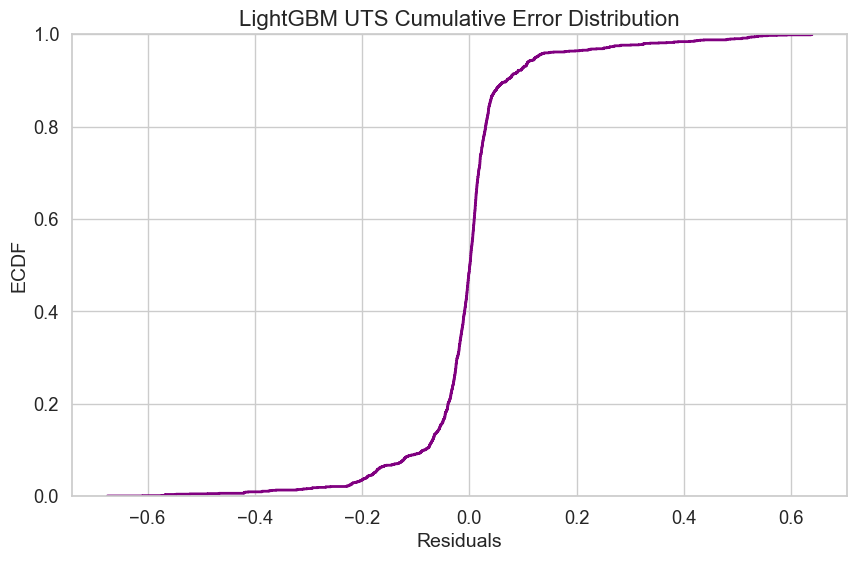

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Data cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Data preparation
columns_to_exclude = ["Conductivity", "elongation", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["UTS"]

# Feature scaling
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(X.select_dtypes(include=["float64", "int64"]))

# Encode categorical variables
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Hyperparameters
params_uts = {
    "n_estimators": 400,
    "learning_rate": 0.015,
    "max_depth": 2,
    "num_leaves": 8,
    "min_child_samples": 450,
    "colsample_bytree": 0.6,
    "feature_fraction": 0.6,
    "bagging_fraction": 0.5,
    "bagging_freq": 5,
    "lambda_l1": 10.0,
    "lambda_l2": 10.0,
    "random_state": 42
}

# Train model
lgb_model_uts = lgb.LGBMRegressor(**params_uts)
lgb_model_uts.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], eval_metric="rmse", callbacks=[lgb.early_stopping(50)])

# Predictions
y_pred = lgb_model_uts.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Print metrics
print("\n🔹 LightGBM UTS Regression Metrics:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# Residuals 
residuals = y_test - y_pred

# Visualizations
output_dir = "lightgbm_uts_plots"
os.makedirs(output_dir, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. LightGBM UTS Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("LightGBM UTS Actual vs. Predicted")
plt.xlabel("Actual UTS")
plt.ylabel("Predicted UTS")
plt.savefig(f"{output_dir}/LightGBM_UTS_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. LightGBM UTS Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_pred, y=residuals, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("LightGBM UTS Residual Plot")
plt.xlabel("Predicted UTS")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir}/LightGBM_UTS_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. LightGBM UTS Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals.mean(), residuals.std()), color="red", linewidth=2)
plt.title("LightGBM UTS Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir}/LightGBM_UTS_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. LightGBM UTS Learning Curves
results = lgb_model_uts.evals_result_
plt.figure(figsize=(10, 6))
plt.plot(results['training']['rmse'], '--', label='Training RMSE', color='blue', linewidth=2)
plt.plot(results['valid_1']['rmse'], '-', label='Validation RMSE', color='orange', linewidth=2)
plt.xlabel("Iterations", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.title("LightGBM UTS Learning Curves")
plt.legend(fontsize=12)
plt.savefig(f"{output_dir}/LightGBM_UTS_Learning_Curves.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 5. LightGBM UTS Hyperparameter vs. Error Plot
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
errors = []
for lr in learning_rates:
    temp_params = params_uts.copy()
    temp_params["learning_rate"] = lr
    model = lgb.LGBMRegressor(**temp_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="rmse", callbacks=[lgb.early_stopping(50)])
    y_pred_temp = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors.append(rmse)

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, errors, marker='o', linewidth=2)
best_lr = learning_rates[np.argmin(errors)]
plt.annotate(f'Optimal LR: {best_lr}', xy=(best_lr, min(errors)), xytext=(best_lr, min(errors)+0.02),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.title("LightGBM UTS Learning Rate vs. RMSE")
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir}/LightGBM_UTS_Hyperparameter_vs_Error.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. LightGBM UTS Feature Importance
plt.figure(figsize=(10, 6))
ax = lgb.plot_importance(lgb_model_uts, max_num_features=10, importance_type="split", color="navy")
plt.title("LightGBM UTS Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir}/LightGBM_UTS_Feature_Importance.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. LightGBM UTS SHAP Summary Plot
explainer = shap.TreeExplainer(lgb_model_uts)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, color='purple')
plt.title("LightGBM UTS SHAP Summary Plot")
plt.savefig(f"{output_dir}/LightGBM_UTS_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. LightGBM UTS Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("LightGBM UTS Q-Q Plot")
plt.savefig(f"{output_dir}/LightGBM_UTS_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. LightGBM UTS Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals, color="purple", linewidth=2)
plt.title("LightGBM UTS Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir}/LightGBM_UTS_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()